<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [4]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-06-17 12:37:51--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  45.1MB/s    in 3.4s    

2026-06-17 12:37:54 (44.9 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



### Step 2: Import necessary libraries and load the dataset


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [6]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [6]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



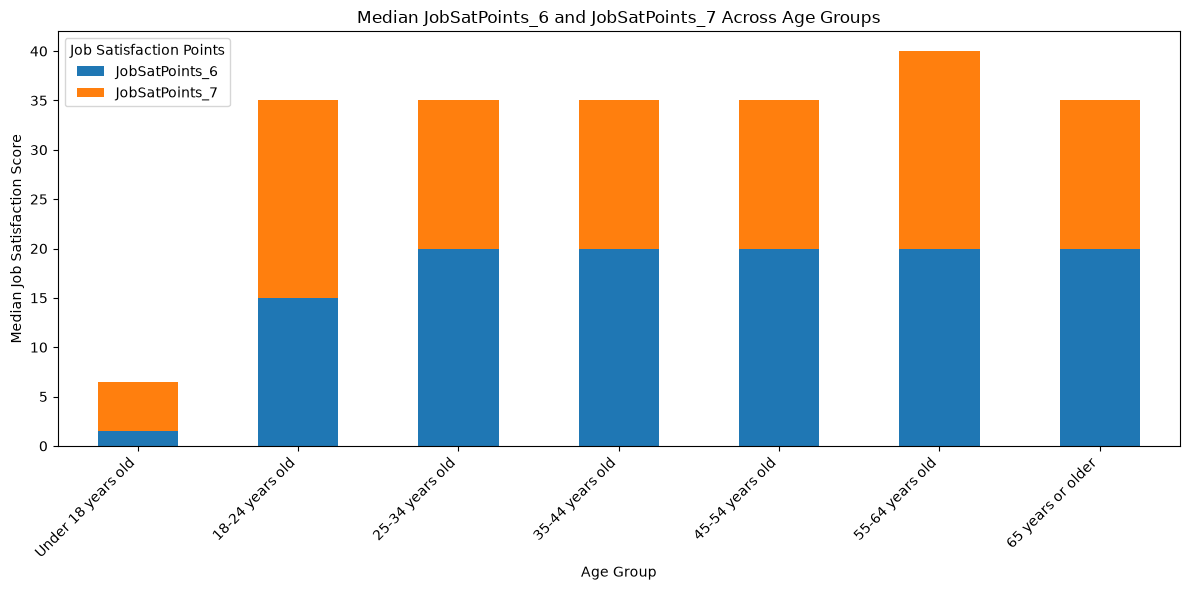

In [7]:
df_stack = df[["Age", "JobSatPoints_6", "JobSatPoints_7"]].copy()

# Clean Age column
df_stack["Age"] = df_stack["Age"].astype("string").str.strip()

# Make sure the satisfaction columns are numeric
df_stack["JobSatPoints_6"] = pd.to_numeric(
    df_stack["JobSatPoints_6"],
    errors="coerce"
)

df_stack["JobSatPoints_7"] = pd.to_numeric(
    df_stack["JobSatPoints_7"],
    errors="coerce"
)

# Age order
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

# Group by Age and calculate median
age_medians = (
    df_stack
    .groupby("Age")[["JobSatPoints_6", "JobSatPoints_7"]]
    .median()
    .reindex(age_order)
)

# Plot stacked bar chart
age_medians.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.xlabel("Age Group")
plt.ylabel("Median Job Satisfaction Score")
plt.title("Median JobSatPoints_6 and JobSatPoints_7 Across Age Groups")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Job Satisfaction Points")

plt.tight_layout()
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


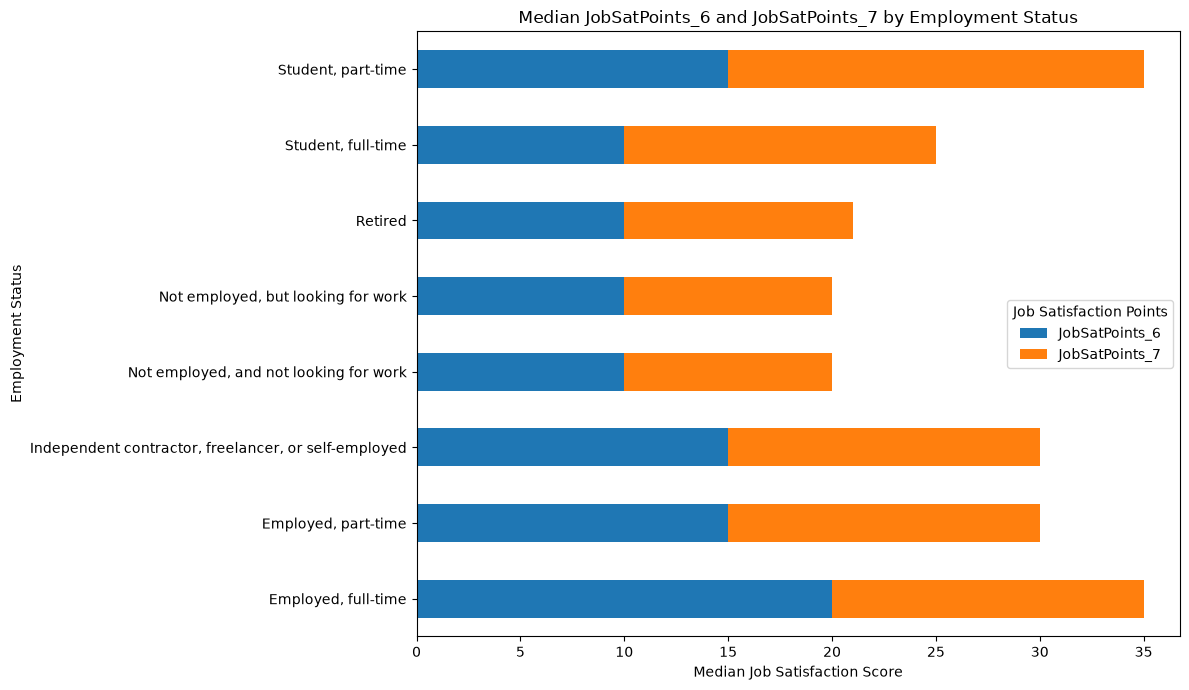

In [11]:
df_stack = df[["Employment", "JobSatPoints_6", "JobSatPoints_7"]].copy()

# Clean Employment column
df_stack["Employment"] = df_stack["Employment"].astype("string").str.strip()

# Make satisfaction columns numeric
df_stack["JobSatPoints_6"] = pd.to_numeric(
    df_stack["JobSatPoints_6"],
    errors="coerce"
)

df_stack["JobSatPoints_7"] = pd.to_numeric(
    df_stack["JobSatPoints_7"],
    errors="coerce"
)

# Remove missing values
df_stack = df_stack.dropna(
    subset=["Employment", "JobSatPoints_6", "JobSatPoints_7"]
)

# Split multiple employment statuses into separate rows
df_stack["Employment"] = df_stack["Employment"].str.split(";")
df_stack = df_stack.explode("Employment")

# Clean again after splitting
df_stack["Employment"] = df_stack["Employment"].astype("string").str.strip()

# Keep top 10 employment statuses so the chart is readable
top_employment = df_stack["Employment"].value_counts().head(10).index
df_stack = df_stack[df_stack["Employment"].isin(top_employment)]

# Group by Employment and calculate median
employment_medians = (
    df_stack
    .groupby("Employment")[["JobSatPoints_6", "JobSatPoints_7"]]
    .median()
)

# Plot stacked chart
employment_medians.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7)
)

plt.xlabel("Median Job Satisfaction Score")
plt.ylabel("Employment Status")
plt.title("Median JobSatPoints_6 and JobSatPoints_7 by Employment Status")

plt.legend(title="Job Satisfaction Points")
plt.tight_layout()
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


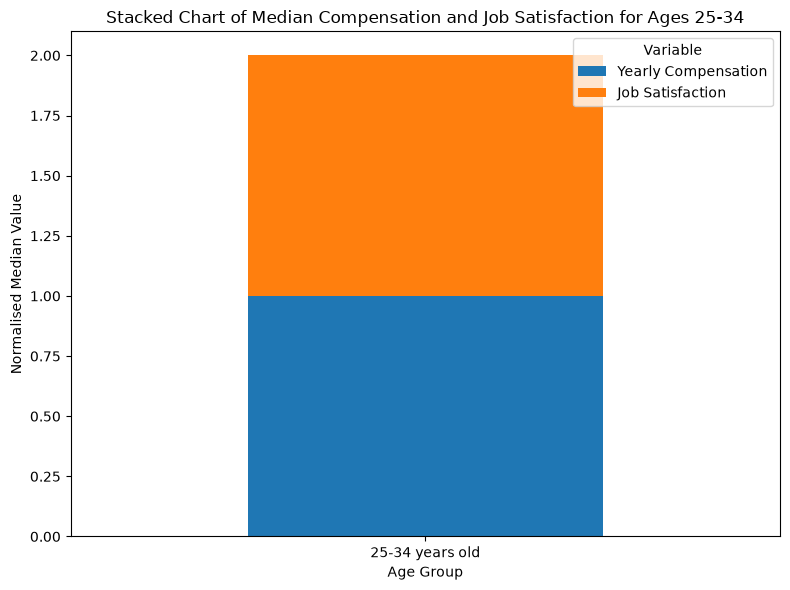

In [9]:
# Select needed columns
df_stack = df[["Age", "ConvertedCompYearly", "JobSatPoints_6"]].copy()

# Clean Age column
df_stack["Age"] = df_stack["Age"].astype("string").str.strip()

# Convert numeric columns
df_stack["ConvertedCompYearly"] = pd.to_numeric(
    df_stack["ConvertedCompYearly"],
    errors="coerce"
)

df_stack["JobSatPoints_6"] = pd.to_numeric(
    df_stack["JobSatPoints_6"],
    errors="coerce"
)

# Drop missing values
df_stack = df_stack.dropna(
    subset=["Age", "ConvertedCompYearly", "JobSatPoints_6"]
)

# Filter to closest available age group to 30-35
age_25_34 = df_stack[df_stack["Age"] == "25-34 years old"].copy()

# Calculate median values for this age group
summary = age_25_34[["ConvertedCompYearly", "JobSatPoints_6"]].median()

# Put into DataFrame for stacked plotting
summary_df = pd.DataFrame({
    "Yearly Compensation": [summary["ConvertedCompYearly"]],
    "Job Satisfaction": [summary["JobSatPoints_6"]]
}, index=["25-34 years old"])

# Normalise values so both are visible on the same stacked chart
summary_normalised = summary_df.copy()
summary_normalised["Yearly Compensation"] = summary_normalised["Yearly Compensation"] / summary_normalised["Yearly Compensation"].max()
summary_normalised["Job Satisfaction"] = summary_normalised["Job Satisfaction"] / summary_normalised["Job Satisfaction"].max()

# Plot stacked bar chart
summary_normalised.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 6)
)

plt.title("Stacked Chart of Median Compensation and Job Satisfaction for Ages 25-34")
plt.xlabel("Age Group")
plt.ylabel("Normalised Median Value")
plt.xticks(rotation=0)
plt.legend(title="Variable")
plt.tight_layout()
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


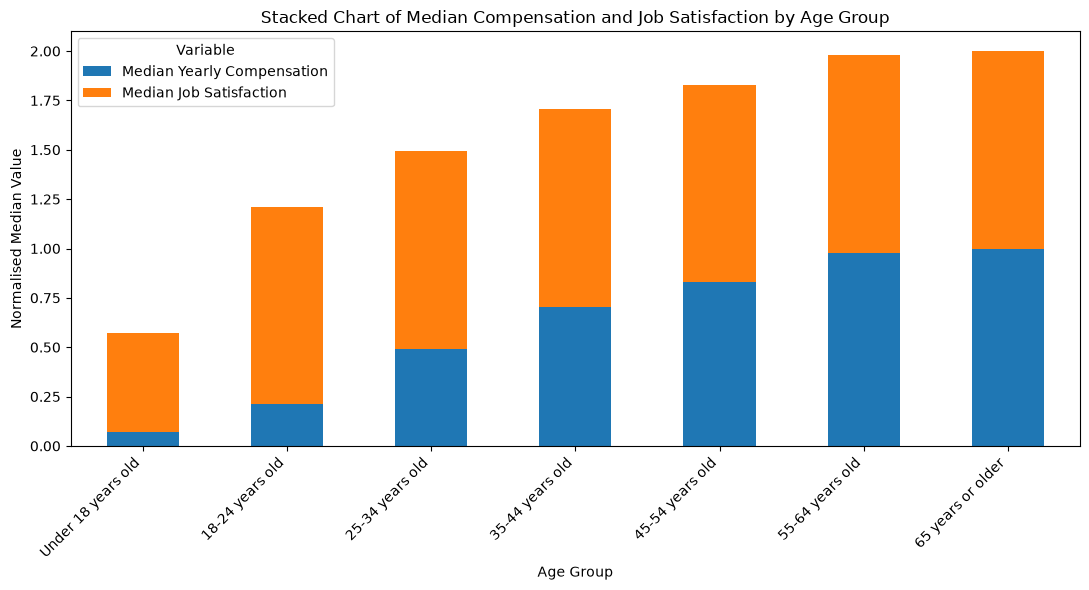

In [10]:
# Select needed columns
df_stack = df[["Age", "ConvertedCompYearly", "JobSatPoints_6"]].copy()

# Clean Age column
df_stack["Age"] = df_stack["Age"].astype("string").str.strip()

# Convert numeric columns
df_stack["ConvertedCompYearly"] = pd.to_numeric(
    df_stack["ConvertedCompYearly"],
    errors="coerce"
)

df_stack["JobSatPoints_6"] = pd.to_numeric(
    df_stack["JobSatPoints_6"],
    errors="coerce"
)

# Remove missing values
df_stack = df_stack.dropna(
    subset=["Age", "ConvertedCompYearly", "JobSatPoints_6"]
)

# Put age groups in order
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

# Keep only these age groups
df_stack = df_stack[df_stack["Age"].isin(age_order)]

# Group by age group and calculate median values
stacked_data = df_stack.groupby("Age")[[
    "ConvertedCompYearly",
    "JobSatPoints_6"
]].median()

# Reorder age groups
stacked_data = stacked_data.reindex(age_order)

# Rename columns for cleaner legend
stacked_data = stacked_data.rename(columns={
    "ConvertedCompYearly": "Median Yearly Compensation",
    "JobSatPoints_6": "Median Job Satisfaction"
})

# Normalise because compensation and job satisfaction are on very different scales
stacked_data_normalised = stacked_data.copy()

stacked_data_normalised["Median Yearly Compensation"] = (
    stacked_data_normalised["Median Yearly Compensation"] /
    stacked_data_normalised["Median Yearly Compensation"].max()
)

stacked_data_normalised["Median Job Satisfaction"] = (
    stacked_data_normalised["Median Job Satisfaction"] /
    stacked_data_normalised["Median Job Satisfaction"].max()
)

# Plot stacked bar chart
stacked_data_normalised.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Stacked Chart of Median Compensation and Job Satisfaction by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Normalised Median Value")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Variable")
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


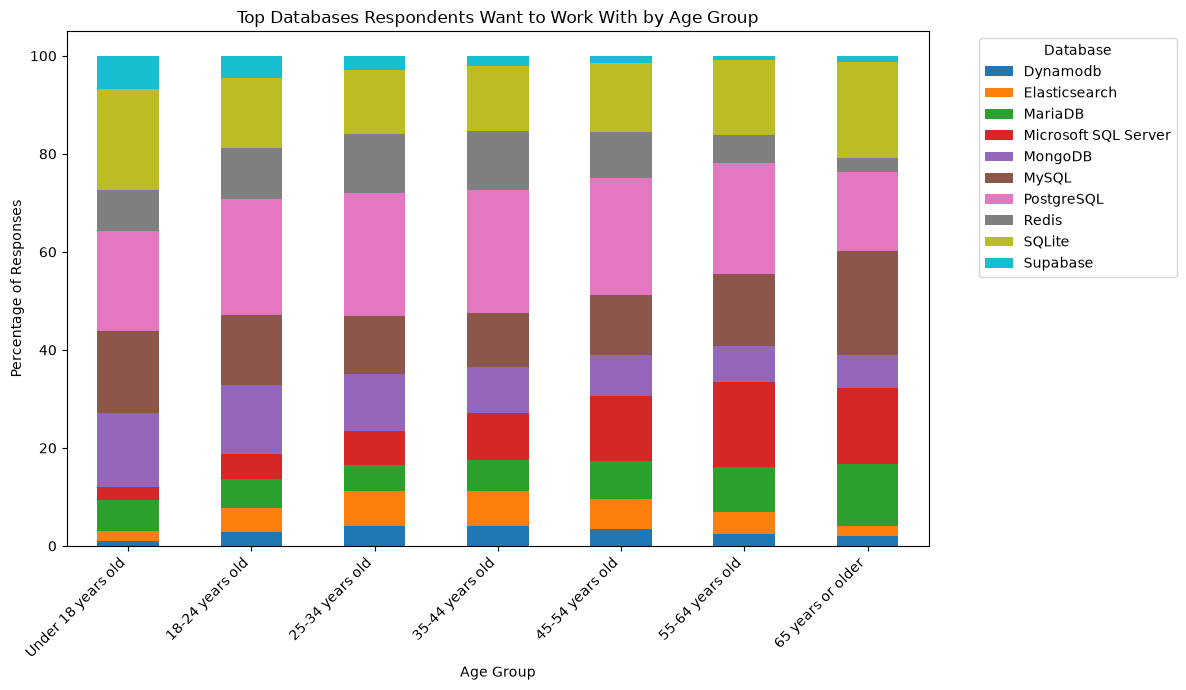

In [15]:
# Remove any duplicate column names just in case
df_clean = df.loc[:, ~df.columns.duplicated()].copy()

# Select columns
df_stack = df_clean[["Age", "DatabaseWantToWorkWith"]].copy()

# Remove missing values
df_stack = df_stack.dropna(subset=["Age", "DatabaseWantToWorkWith"])

# Clean text
df_stack["Age"] = df_stack["Age"].astype(str).str.strip()
df_stack["DatabaseWantToWorkWith"] = df_stack["DatabaseWantToWorkWith"].astype(str).str.strip()

# Split multiple database answers
df_stack["DatabaseWantToWorkWith"] = df_stack["DatabaseWantToWorkWith"].str.split(";")

# Explode into separate rows and reset index to avoid duplicate index error
df_stack = df_stack.explode("DatabaseWantToWorkWith").reset_index(drop=True)

# Clean database names again
df_stack["DatabaseWantToWorkWith"] = df_stack["DatabaseWantToWorkWith"].astype(str).str.strip()

# Remove blank database entries
df_stack = df_stack[df_stack["DatabaseWantToWorkWith"] != ""]

# Age group order
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

# Keep only valid age groups
df_stack = df_stack[df_stack["Age"].isin(age_order)].reset_index(drop=True)

# Get top 10 databases overall
top_databases = df_stack["DatabaseWantToWorkWith"].value_counts().head(10).index.tolist()

# Keep only top databases
df_top = df_stack[df_stack["DatabaseWantToWorkWith"].isin(top_databases)].reset_index(drop=True)

# Count database choices by age group
database_age_table = (
    df_top
    .groupby(["Age", "DatabaseWantToWorkWith"])
    .size()
    .unstack(fill_value=0)
)

# Put age groups in the correct order without using reindex
ordered_ages = [age for age in age_order if age in database_age_table.index]
database_age_table = database_age_table.loc[ordered_ages]

# Convert counts to percentages within each age group
database_age_percent = database_age_table.div(
    database_age_table.sum(axis=1),
    axis=0
) * 100

# Plot stacked bar chart
database_age_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Top Databases Respondents Want to Work With by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage of Responses")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Database", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


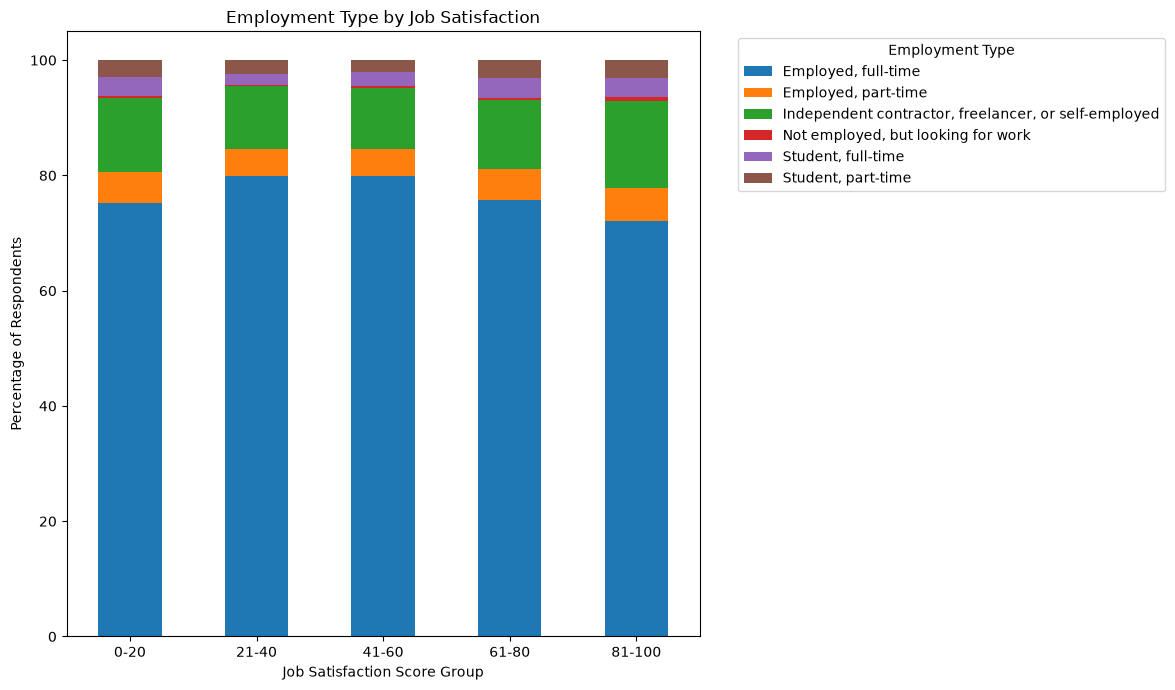

In [16]:
# Select needed columns
df_emp = df[["Employment", "JobSatPoints_6"]].copy()

# Clean columns
df_emp["Employment"] = df_emp["Employment"].astype("string").str.strip()
df_emp["JobSatPoints_6"] = pd.to_numeric(df_emp["JobSatPoints_6"], errors="coerce")

# Remove missing values
df_emp = df_emp.dropna(subset=["Employment", "JobSatPoints_6"])

# Group job satisfaction into bands so x-axis is cleaner
df_emp["Job Satisfaction Group"] = pd.cut(
    df_emp["JobSatPoints_6"],
    bins=[-1, 20, 40, 60, 80, 100],
    labels=["0-20", "21-40", "41-60", "61-80", "81-100"]
)

# Split multiple employment answers
df_emp["Employment"] = df_emp["Employment"].str.split(";")
df_emp = df_emp.explode("Employment").reset_index(drop=True)
df_emp["Employment"] = df_emp["Employment"].astype("string").str.strip()

# Keep top employment types to make chart readable
top_employment = df_emp["Employment"].value_counts().head(6).index.tolist()
df_emp_top = df_emp[df_emp["Employment"].isin(top_employment)].reset_index(drop=True)

# Create percentage table
employment_table = pd.crosstab(
    df_emp_top["Job Satisfaction Group"],
    df_emp_top["Employment"],
    normalize="index"
) * 100

# Plot stacked chart
employment_table.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Employment Type by Job Satisfaction")
plt.xlabel("Job Satisfaction Score Group")
plt.ylabel("Percentage of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Employment Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


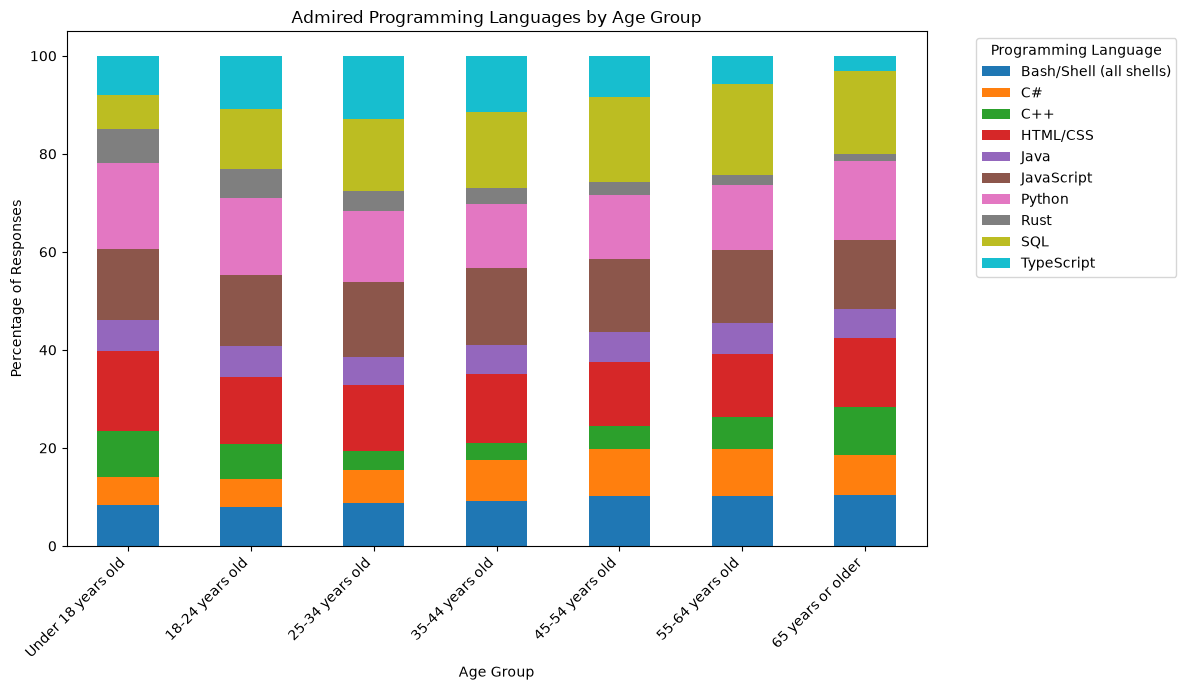

In [17]:
# Select needed columns
df_lang = df[["Age", "LanguageAdmired"]].copy()

# Clean columns
df_lang["Age"] = df_lang["Age"].astype("string").str.strip()
df_lang["LanguageAdmired"] = df_lang["LanguageAdmired"].astype("string").str.strip()

# Remove missing values
df_lang = df_lang.dropna(subset=["Age", "LanguageAdmired"])

# Split multiple language answers
df_lang["LanguageAdmired"] = df_lang["LanguageAdmired"].str.split(";")
df_lang = df_lang.explode("LanguageAdmired").reset_index(drop=True)
df_lang["LanguageAdmired"] = df_lang["LanguageAdmired"].astype("string").str.strip()

# Age group order
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

# Keep valid age groups
df_lang = df_lang[df_lang["Age"].isin(age_order)].reset_index(drop=True)

# Keep top 10 languages
top_languages = df_lang["LanguageAdmired"].value_counts().head(10).index.tolist()
df_lang_top = df_lang[df_lang["LanguageAdmired"].isin(top_languages)].reset_index(drop=True)

# Create percentage table
language_table = pd.crosstab(
    df_lang_top["Age"],
    df_lang_top["LanguageAdmired"],
    normalize="index"
) * 100

# Put age groups in correct order
ordered_ages = [age for age in age_order if age in language_table.index]
language_table = language_table.loc[ordered_ages]

# Plot stacked chart
language_table.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Admired Programming Languages by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage of Responses")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Programming Language", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


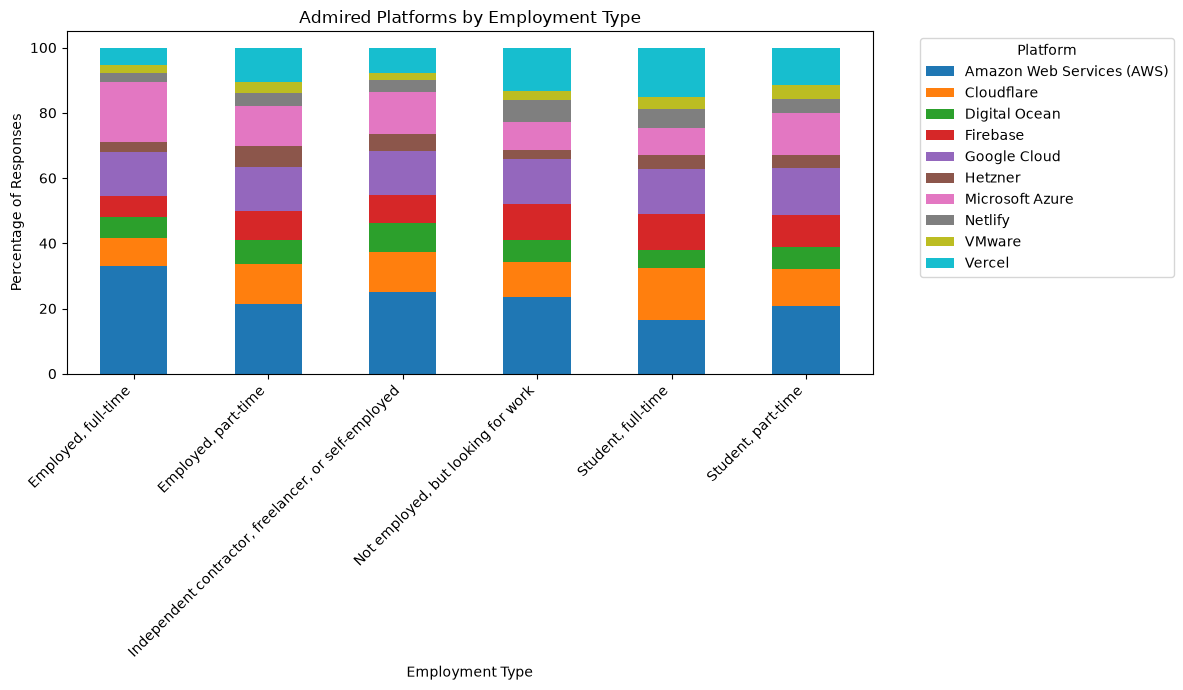

In [18]:
# Select needed columns
df_platform = df[["Employment", "PlatformAdmired"]].copy()

# Clean columns
df_platform["Employment"] = df_platform["Employment"].astype("string").str.strip()
df_platform["PlatformAdmired"] = df_platform["PlatformAdmired"].astype("string").str.strip()

# Remove missing values
df_platform = df_platform.dropna(subset=["Employment", "PlatformAdmired"])

# Split multiple employment answers
df_platform["Employment"] = df_platform["Employment"].str.split(";")
df_platform = df_platform.explode("Employment").reset_index(drop=True)
df_platform["Employment"] = df_platform["Employment"].astype("string").str.strip()

# Split multiple platform answers
df_platform["PlatformAdmired"] = df_platform["PlatformAdmired"].str.split(";")
df_platform = df_platform.explode("PlatformAdmired").reset_index(drop=True)
df_platform["PlatformAdmired"] = df_platform["PlatformAdmired"].astype("string").str.strip()

# Keep top employment types and top platforms for readability
top_employment = df_platform["Employment"].value_counts().head(6).index.tolist()
top_platforms = df_platform["PlatformAdmired"].value_counts().head(10).index.tolist()

df_platform_top = df_platform[
    (df_platform["Employment"].isin(top_employment)) &
    (df_platform["PlatformAdmired"].isin(top_platforms))
].reset_index(drop=True)

# Create percentage table
platform_table = pd.crosstab(
    df_platform_top["Employment"],
    df_platform_top["PlatformAdmired"],
    normalize="index"
) * 100

# Plot stacked chart
platform_table.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Admired Platforms by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Percentage of Responses")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Platform", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
